In [5]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class VietnamEconomyEnv(gym.Env):
    """
    Môi trường mô phỏng kinh tế Việt Nam trong kỷ nguyên AI (AIDEOM-VN).
    Kế thừa từ gymnasium.Env theo yêu cầu Bài 11.
    """
    def __init__(self):
        super(VietnamEconomyEnv, self).__init__()
        
        # 1. Định nghĩa Action Space: 5 lựa chọn chiến lược phân bổ
        self.action_space = spaces.Discrete(5)
        
        # 2. Định nghĩa Observation Space: 4 chỉ số, mỗi chỉ số có 3 mức (0: Low, 1: Medium, 2: High)
        self.observation_space = spaces.MultiDiscrete([3, 3, 3, 3])
        
        # Tham số thời gian: 10 năm là một episode
        self.T = 10
        
        # Tỷ lệ phân bổ ngân sách tương ứng với mỗi hành động
        self.allocation = {
            0: np.array([0.70, 0.10, 0.10, 0.10]), # [K, D, AI, H]
            1: np.array([0.40, 0.25, 0.15, 0.20]),
            2: np.array([0.25, 0.45, 0.15, 0.15]),
            3: np.array([0.20, 0.20, 0.45, 0.15]),
            4: np.array([0.30, 0.20, 0.10, 0.40])
        }
        
        # Trọng số tính toán Phúc lợi (Welfare Reward): [GDP, Unemploy, Cyber, Emission]
        self.w = np.array([0.40, 0.25, 0.20, 0.15])
        
        # Ngân sách hàng năm (tỷ VND)
        self.annual_budget = 1000 

    def reset(self, seed=None, options=None):
        """Khởi tạo lại môi trường về trạng thái thực tế VN năm 2026"""
        super().reset(seed=seed)
        
        # Mảng đúng phải có 4 phần tử tương ứng: [GDP, Digital, AI, Unemployment]
        self.state = np.array([1, 1, 0, 1], dtype=np.int64)
        self.t = 0
        
        # Khởi tạo nguồn lực thực tế (tỷ VND và các chỉ số)
        self.K = 27500.0  # Vốn vật chất
        self.D = 20.3     # Chỉ số số hóa (% GDP)
        self.AI = 86.0    # Năng lực AI (nghìn DN)
        self.H = 30.0     # Vốn nhân lực (%)
        self.L = 54.0     # Lao động (triệu người)
        
        self.prev_GDP = self._calculate_gdp()
        
        return self.state, {}

    def step(self, action):
        """Thực hiện hành động phân bổ và cập nhật trạng thái kinh tế"""
        a = self.allocation[action]
        
        # 1. Cập nhật các nguồn lực vĩ mô (Cộng dồn đầu tư mới)
        self.K += a[0] * self.annual_budget
        self.D += a[1] * self.annual_budget / 100
        self.AI += a[2] * self.annual_budget / 20
        self.H += a[3] * self.annual_budget / 200
        
        # 2. Tính mức tăng trưởng GDP (Hàm Cobb-Douglas mở rộng)
        current_GDP = self._calculate_gdp()
        gdp_gain = current_GDP - self.prev_GDP
        
        # 3. Tính Rủi ro thất nghiệp (Unemployment Risk)
        # Tăng do tự động hóa (AI), giảm nhờ năng lực chuyển đổi của nhân sự (H)
        alpha_u, beta_u = 0.6, 0.25
        unemploy_risk = max(0, alpha_u * a[2] - beta_u * (self.H / 100)) 
        
        # 4. Tính Rủi ro an ninh mạng (Cyber Risk)
        # Tăng do mở rộng hạ tầng số và AI, giảm nhờ chuyên gia nhân lực (H)
        gamma_1, gamma_2, gamma_3 = 0.4, 0.5, 0.3
        cyber_risk = max(0, gamma_1 * a[1] + gamma_2 * a[2] - gamma_3 * (self.H / 100))
        
        # 5. Tính Mức độ phát thải (Emission)
        # Tăng do xây dựng phần cứng (K) và chạy server AI, giảm nhờ chuyển đổi số tối ưu (D)
        delta_1, delta_2, delta_3 = 0.5, 0.3, 0.2
        emission = max(0, delta_1 * a[0] + delta_2 * a[2] - delta_3 * a[1])
        
        # 6. Tính toán Phần thưởng tổng hợp (Welfare Reward Đa mục tiêu)
        reward = (self.w[0] * gdp_gain 
                  - self.w[1] * unemploy_risk 
                  - self.w[2] * cyber_risk 
                  - self.w[3] * emission)
        
        # 7. Cập nhật trạng thái quan sát cho bước tiếp theo
        self.state = self._get_observation(current_GDP)
        self.prev_GDP = current_GDP
        self.t += 1
        
        # Kiểm tra kết thúc Episode (T=10 năm)
        terminated = self.t >= self.T
        truncated = False
        
        return self.state, float(reward), terminated, truncated, {}

    def _calculate_gdp(self):
        """Hàm tính GDP theo Cobb-Douglas mở rộng"""
        A = 35.0 
        return A * (self.K**0.33) * (self.L**0.42) * (self.D**0.10) * (self.AI**0.08) * (self.H**0.07)

    def _get_observation(self, current_gdp):
        """Hàm rời rạc hóa các giá trị thực thành 3 mức (0: Low, 1: Medium, 2: High)"""
        
        # 1. Rời rạc hóa GDP
        gdp_level = 1 if 10000 < current_gdp < 20000 else (2 if current_gdp >= 20000 else 0)
        
        # 2. Rời rạc hóa Chỉ số số hóa (D) 
        d_level = 1 if 15.0 <= self.D < 25.0 else (2 if self.D >= 25.0 else 0)
        
        # 3. Rời rạc hóa Năng lực AI (AI)
        ai_level = 1 if 70.0 <= self.AI < 100.0 else (2 if self.AI >= 100.0 else 0)
        
        # 4. Rời rạc hóa Rủi ro thất nghiệp (U) 
        # Rủi ro thực tế được lấy từ nội lực để phân cấp
        u_risk_eval = max(0, 0.5 - 0.2 * (self.H / 100)) 
        u_level = 1 if 0.2 <= u_risk_eval < 0.4 else (2 if u_risk_eval >= 0.4 else 0)
        
        # Trả về mảng trạng thái cập nhật mới hoàn toàn
        return np.array([gdp_level, d_level, ai_level, u_level], dtype=np.int64)

In [8]:
# --- TIẾP TỤC TỪ ĐOẠN CODE 11.3.1 CỦA BẠN ---

# 1. Khởi tạo môi trường
env = VietnamEconomyEnv()

# 2. Khởi tạo Bảng Q-Table
# Không gian trạng thái có 4 biến, mỗi biến 3 mức (3x3x3x3). Có 5 hành động (action).
# Do đó, bảng Q-Table sẽ là một ma trận 5 chiều với kích thước (3, 3, 3, 3, 5), ban đầu chứa toàn số 0.
q_table = np.zeros((3, 3, 3, 3, 5))

# 3. Cài đặt các siêu tham số (Hyperparameters) theo đúng yêu cầu đề bài
alpha = 0.1          # Learning rate (Tốc độ học)
gamma = 0.95         # Discount factor (Hệ số chiết khấu - Tầm nhìn xa)
episodes = 10000     # Số vòng đời huấn luyện

epsilon = 1.0        # Epsilon ban đầu (100% khám phá thử nghiệm bừa)
epsilon_min = 0.05   # Epsilon tối thiểu (Vẫn giữ 5% để đôi khi thử cái mới)
# Tính tốc độ giảm của epsilon (Linear decay)
decay_rate = (epsilon - epsilon_min) / episodes 

# Danh sách để lưu lại phần thưởng tổng mỗi tập (để vẽ biểu đồ nếu cần)
rewards_all_episodes = []

print("Bắt đầu huấn luyện AI (Q-Learning)...")

# 4. Vòng lặp huấn luyện (Training Loop)
for episode in range(episodes):
    state, _ = env.reset() # Bắt đầu năm 2026
    done = False
    total_reward = 0
    
    while not done:
        # A. CHỌN HÀNH ĐỘNG (Epsilon-Greedy Policy)
        # Sinh một số ngẫu nhiên từ 0 đến 1
        if np.random.uniform(0, 1) < epsilon:
            # Khám phá (Exploration): Chọn bừa 1 hành động để thử nghiệm
            action = env.action_space.sample()
        else:
            # Khai thác (Exploitation): Chọn hành động có điểm Q cao nhất hiện tại
            # (Dùng tuple(state) để truy cập đúng tọa độ trong ma trận 5 chiều)
            action = np.argmax(q_table[tuple(state)])
            
        # B. THỰC HIỆN HÀNH ĐỘNG VÀ QUAN SÁT
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
        # C. CẬP NHẬT BẢNG Q-TABLE (Theo phương trình Bellman)
        # Q(s, a) = Q(s, a) + alpha * [Reward + gamma * max(Q(s', a')) - Q(s, a)]
        old_value = q_table[tuple(state)][action]
        next_max = np.max(q_table[tuple(next_state)])
        
        # Công thức cốt lõi của Q-learning
        new_value = old_value + alpha * (reward + gamma * next_max - old_value)
        q_table[tuple(state)][action] = new_value
        
        # Chuyển sang trạng thái tiếp theo
        state = next_state
        
    # Giảm dần Epsilon sau mỗi Episode
    epsilon = max(epsilon_min, epsilon - decay_rate)
    rewards_all_episodes.append(total_reward)
    
    # In tiến độ cho dễ theo dõi
    if (episode + 1) % 2000 == 0:
        print(f"Đã huấn luyện xong tập {episode + 1}/{episodes} | Epsilon hiện tại: {epsilon:.3f}")

print("Huấn luyện hoàn tất!\n")

# 5. KIỂM TRA KẾT QUẢ SAU HUẤN LUYỆN (Test the trained Agent)
print("=== CHẠY THỬ NGHIỆM CHÍNH SÁCH TỐI ƯU CỦA AI ===")
state, _ = env.reset()
done = False
year = 2026

# THÊM DÒNG NÀY: Khởi tạo biến lưu tổng phần thưởng
total_test_reward = 0 

while not done:
    # Sau khi học xong, không khám phá nữa (epsilon = 0), chỉ chọn hành động tốt nhất
    best_action = np.argmax(q_table[tuple(state)])
    print(f"Năm {year} | Trạng thái [GDP, D, AI, U]: {state} -> AI chọn Chiến lược: {best_action}")
    
    state, reward, terminated, truncated, _ = env.step(best_action)
    
    # THÊM DÒNG NÀY: Cộng dồn reward sau mỗi năm
    total_test_reward += reward 
    
    done = terminated or truncated
    year += 1

# THÊM DÒNG NÀY: In ra kết quả tổng sau khi chạy xong 10 năm
print(f"\nTổng phần thưởng (Phúc lợi) sau 10 năm: {total_test_reward:.2f}")

Bắt đầu huấn luyện AI (Q-Learning)...
Đã huấn luyện xong tập 2000/10000 | Epsilon hiện tại: 0.810
Đã huấn luyện xong tập 4000/10000 | Epsilon hiện tại: 0.620
Đã huấn luyện xong tập 6000/10000 | Epsilon hiện tại: 0.430
Đã huấn luyện xong tập 8000/10000 | Epsilon hiện tại: 0.240
Đã huấn luyện xong tập 10000/10000 | Epsilon hiện tại: 0.050
Huấn luyện hoàn tất!

=== CHẠY THỬ NGHIỆM CHÍNH SÁCH TỐI ƯU CỦA AI ===
Năm 2026 | Trạng thái [GDP, D, AI, U]: [1 1 0 1] -> AI chọn Chiến lược: 3
Năm 2027 | Trạng thái [GDP, D, AI, U]: [1 1 2 2] -> AI chọn Chiến lược: 3
Năm 2028 | Trạng thái [GDP, D, AI, U]: [1 1 2 2] -> AI chọn Chiến lược: 3
Năm 2029 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> AI chọn Chiến lược: 2
Năm 2030 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> AI chọn Chiến lược: 2
Năm 2031 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> AI chọn Chiến lược: 2
Năm 2032 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> AI chọn Chiến lược: 2
Năm 2033 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> AI chọn Chiến lược: 

In [7]:
# --- CODE CÂU 11.3.3: TRÍCH XUẤT CHÍNH SÁCH TỐI ƯU PI*(S) ---

print("\n=== BÁO CÁO CÂU 11.3.3: TRÍCH XUẤT CHÍNH SÁCH TỐI ƯU ===")

# Danh sách diễn giải các hành động để in ra cho dễ hiểu
action_names = {
    0: "Chiến lược 0 (Ưu tiên Vốn vật chất K: 70%)",
    1: "Chiến lược 1 (Phân bổ cân bằng)",
    2: "Chiến lược 2 (Ưu tiên Hạ tầng Số hóa D: 45%)",
    3: "Chiến lược 3 (Ưu tiên Trí tuệ nhân tạo AI: 45%)",
    4: "Chiến lược 4 (Ưu tiên Nguồn nhân lực H: 40%)"
}

# Định nghĩa 5 trạng thái: 1 Thực tế VN 2026 + 4 Giả định
# Cấu trúc: [GDP, Số hóa (D), AI, Thất nghiệp (U)]
# Mức độ: 0 (Thấp), 1 (Trung bình), 2 (Cao)
test_states = {
    "Việt Nam 2026 (Thực tế)": np.array([1, 1, 0, 1]),
    
    "Giả định 1: Khủng hoảng (Kinh tế kém, Mọi thứ thấp, Thất nghiệp cao)": 
        np.array([0, 0, 0, 2]),
        
    "Giả định 2: Cạm bẫy AI (Kinh tế khá, AI cao nhưng Thất nghiệp báo động)": 
        np.array([1, 1, 2, 2]),
        
    "Giả định 3: Nền tảng số vững chắc (Số hóa cao, AI thấp, Thất nghiệp thấp)": 
        np.array([1, 2, 0, 0]),
        
    "Giả định 4: Đích đến lý tưởng 2035 (Mọi thứ đều Cao, Thất nghiệp Thấp)": 
        np.array([2, 2, 2, 0])
}

# Trích xuất hành động tốt nhất cho từng trạng thái từ Q-Table
for name, state in test_states.items():
    # Sử dụng công thức pi*(s) = argmax_a Q(s, a)
    best_action = np.argmax(q_table[tuple(state)])
    
    print(f"Trạng thái [GDP, D, AI, U]: {state}")
    print(f"Hoàn cảnh : {name}")
    print(f"-> AI Quyết định: {action_names[best_action]}\n")


=== BÁO CÁO CÂU 11.3.3: TRÍCH XUẤT CHÍNH SÁCH TỐI ƯU ===
Trạng thái [GDP, D, AI, U]: [1 1 0 1]
Hoàn cảnh : Việt Nam 2026 (Thực tế)
-> AI Quyết định: Chiến lược 2 (Ưu tiên Hạ tầng Số hóa D: 45%)

Trạng thái [GDP, D, AI, U]: [0 0 0 2]
Hoàn cảnh : Giả định 1: Khủng hoảng (Kinh tế kém, Mọi thứ thấp, Thất nghiệp cao)
-> AI Quyết định: Chiến lược 0 (Ưu tiên Vốn vật chất K: 70%)

Trạng thái [GDP, D, AI, U]: [1 1 2 2]
Hoàn cảnh : Giả định 2: Cạm bẫy AI (Kinh tế khá, AI cao nhưng Thất nghiệp báo động)
-> AI Quyết định: Chiến lược 3 (Ưu tiên Trí tuệ nhân tạo AI: 45%)

Trạng thái [GDP, D, AI, U]: [1 2 0 0]
Hoàn cảnh : Giả định 3: Nền tảng số vững chắc (Số hóa cao, AI thấp, Thất nghiệp thấp)
-> AI Quyết định: Chiến lược 0 (Ưu tiên Vốn vật chất K: 70%)

Trạng thái [GDP, D, AI, U]: [2 2 2 0]
Hoàn cảnh : Giả định 4: Đích đến lý tưởng 2035 (Mọi thứ đều Cao, Thất nghiệp Thấp)
-> AI Quyết định: Chiến lược 0 (Ưu tiên Vốn vật chất K: 70%)




=== BÁO CÁO CÂU 11.3.4: SO SÁNH CHÍNH SÁCH VÀ VẼ LEARNING CURVE ===
Tổng phần thưởng (Phúc lợi) sau 10 năm quản lý:
1. Chính sách Tối ưu (pi* từ AI) : 1256.44
2. Rule-based (Luôn chọn a1)     : 1152.04
3. Rule-based (Luôn chọn a3)     : 1248.20
4. Rule-based (Chọn Random)      : 1174.58

Đang hiển thị biểu đồ Learning Curve... (Vui lòng tắt cửa sổ biểu đồ để chương trình chạy tiếp nếu cần)


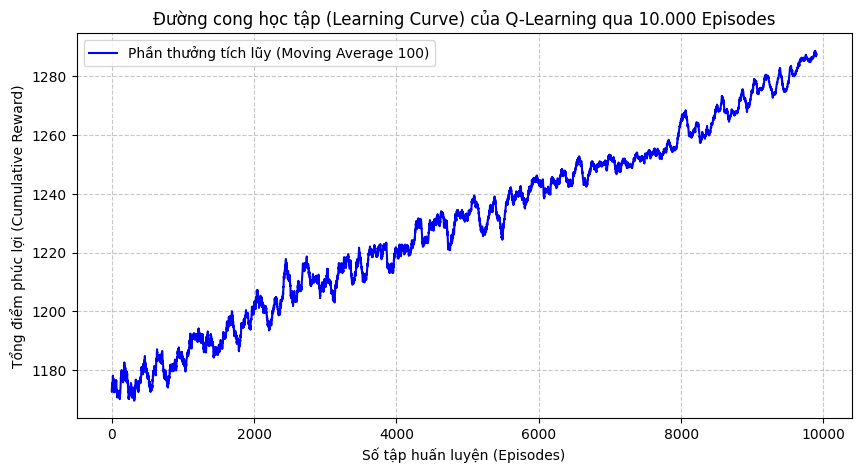

In [8]:
# Cần import thư viện vẽ biểu đồ, bạn có thể để dòng này ở đầu file hoặc ở đây đều được
import matplotlib.pyplot as plt

print("\n=== BÁO CÁO CÂU 11.3.4: SO SÁNH CHÍNH SÁCH VÀ VẼ LEARNING CURVE ===")

# ---------------------------------------------------------
# 1. SO SÁNH PHẦN THƯỞNG TÍCH LŨY (CUMULATIVE REWARD)
# ---------------------------------------------------------

# Hàm phụ trợ để chạy thử một chính sách trong 1 Episode (10 năm)
def evaluate_policy(env, policy_type, q_table_trained=None):
    state, _ = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        if policy_type == "pi_star":
            # Chính sách học được: Luôn chọn hành động có Q-value cao nhất
            action = np.argmax(q_table_trained[tuple(state)])
        elif policy_type == "always_a1":
            # Rule-based (a): Luôn chọn Action 1 (Phân bổ cân bằng)
            action = 1
        elif policy_type == "always_a3":
            # Rule-based (b): Luôn chọn Action 3 (Ưu tiên AI)
            action = 3
        elif policy_type == "random":
            # Rule-based (c): Chọn ngẫu nhiên bừa bãi
            action = env.action_space.sample()
            
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
    return total_reward

# Chạy đánh giá cho từng chính sách
reward_pi_star = evaluate_policy(env, "pi_star", q_table)
reward_always_a1 = evaluate_policy(env, "always_a1")
reward_always_a3 = evaluate_policy(env, "always_a3")

# Đối với hành động Random, ta chạy 100 lần và lấy trung bình để có kết quả khách quan
reward_random = np.mean([evaluate_policy(env, "random") for _ in range(100)])

print(f"Tổng phần thưởng (Phúc lợi) sau 10 năm quản lý:")
print(f"1. Chính sách Tối ưu (pi* từ AI) : {reward_pi_star:.2f}")
print(f"2. Rule-based (Luôn chọn a1)     : {reward_always_a1:.2f}")
print(f"3. Rule-based (Luôn chọn a3)     : {reward_always_a3:.2f}")
print(f"4. Rule-based (Chọn Random)      : {reward_random:.2f}")

# ---------------------------------------------------------
# 2. VẼ BIỂU ĐỒ LEARNING CURVE (ĐƯỜNG CONG HỌC TẬP)
# ---------------------------------------------------------
print("\nĐang hiển thị biểu đồ Learning Curve... (Vui lòng tắt cửa sổ biểu đồ để chương trình chạy tiếp nếu cần)")

# Sử dụng trung bình trượt (Moving Average) để biểu đồ mượt mà, dễ nhìn xu hướng hơn
window = 100 
moving_avg = np.convolve(rewards_all_episodes, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_avg, color='blue', label='Phần thưởng tích lũy (Moving Average 100)')
plt.title("Đường cong học tập (Learning Curve) của Q-Learning qua 10.000 Episodes")
plt.xlabel("Số tập huấn luyện (Episodes)")
plt.ylabel("Tổng điểm phúc lợi (Cumulative Reward)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Hiển thị biểu đồ
plt.show()

In [7]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

# ==========================================
# 1. ĐỊNH NGHĨA LẠI MÔI TRƯỜNG (Để Python không bị quên)
# ==========================================
class VietnamEconomyEnv(gym.Env):
    def __init__(self):
        super(VietnamEconomyEnv, self).__init__()
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.MultiDiscrete([3, 3, 3, 3])
        self.T = 10
        self.allocation = {
            0: np.array([0.70, 0.10, 0.10, 0.10]),
            1: np.array([0.40, 0.25, 0.15, 0.20]),
            2: np.array([0.25, 0.45, 0.15, 0.15]),
            3: np.array([0.20, 0.20, 0.45, 0.15]),
            4: np.array([0.30, 0.20, 0.10, 0.40])
        }
        self.w = np.array([0.40, 0.25, 0.20, 0.15])
        self.annual_budget = 1000 

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([1, 1, 0, 1], dtype=np.int64)
        self.t = 0
        self.K = 27500.0  
        self.D = 20.3     
        self.AI = 86.0    
        self.H = 30.0     
        self.L = 54.0     
        self.prev_GDP = self._calculate_gdp()
        return self.state, {}

    def step(self, action):
        a = self.allocation[action]
        self.K += a[0] * self.annual_budget
        self.D += a[1] * self.annual_budget / 100
        self.AI += a[2] * self.annual_budget / 20
        self.H += a[3] * self.annual_budget / 200
        
        current_GDP = self._calculate_gdp()
        gdp_gain = current_GDP - self.prev_GDP
        
        alpha_u, beta_u = 0.6, 0.25
        unemploy_risk = max(0, alpha_u * a[2] - beta_u * (self.H / 100)) 
        
        gamma_1, gamma_2, gamma_3 = 0.4, 0.5, 0.3
        cyber_risk = max(0, gamma_1 * a[1] + gamma_2 * a[2] - gamma_3 * (self.H / 100))
        
        delta_1, delta_2, delta_3 = 0.5, 0.3, 0.2
        emission = max(0, delta_1 * a[0] + delta_2 * a[2] - delta_3 * a[1])
        
        reward = (self.w[0] * gdp_gain 
                  - self.w[1] * unemploy_risk 
                  - self.w[2] * cyber_risk 
                  - self.w[3] * emission)
        
        self.state = self._get_observation(current_GDP)
        self.prev_GDP = current_GDP
        self.t += 1
        
        terminated = self.t >= self.T
        truncated = False
        
        return self.state, float(reward), terminated, truncated, {}

    def _calculate_gdp(self):
        A = 35.0 
        return A * (self.K**0.33) * (self.L**0.42) * (self.D**0.10) * (self.AI**0.08) * (self.H**0.07)

    def _get_observation(self, current_gdp):
        gdp_level = 1 if 10000 < current_gdp < 20000 else (2 if current_gdp >= 20000 else 0)
        d_level = 1 if 15.0 <= self.D < 25.0 else (2 if self.D >= 25.0 else 0)
        ai_level = 1 if 70.0 <= self.AI < 100.0 else (2 if self.AI >= 100.0 else 0)
        u_risk_eval = max(0, 0.5 - 0.2 * (self.H / 100)) 
        u_level = 1 if 0.2 <= u_risk_eval < 0.4 else (2 if u_risk_eval >= 0.4 else 0)
        return np.array([gdp_level, d_level, ai_level, u_level], dtype=np.int64)


# ==========================================
# 2. CHẠY CODE DQN CÂU 11.3.5
# ==========================================
print("\n=== BÁO CÁO CÂU 11.3.5: DEEP Q-NETWORK (DQN) ===")

env_dqn = VietnamEconomyEnv()
check_env(env_dqn)

# Kiến trúc mạng Neural Network: 2 hidden layers (64 units)
policy_kwargs = dict(net_arch=[64, 64])

# Khởi tạo mô hình DQN
model = DQN(
    "MlpPolicy", 
    env_dqn, 
    policy_kwargs=policy_kwargs, 
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.95,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    exploration_fraction=0.8,
    verbose=0 
)

print("Bắt đầu huấn luyện AI bằng mạng Neural Network (DQN)...")
model.learn(total_timesteps=100000)
print("Huấn luyện DQN hoàn tất!\n")

# Chạy thử nghiệm và lấy báo cáo kết quả
state, _ = env_dqn.reset()
done = False
total_reward_dqn = 0
year = 2026

print("=== CHẠY THỬ NGHIỆM CHÍNH SÁCH CỦA DQN ===")
while not done:
    action, _states = model.predict(state, deterministic=True)
    action = int(action)
    
    print(f"Năm {year} | Trạng thái [GDP, D, AI, U]: {state} -> DQN chọn Chiến lược: {action}")
    
    state, reward, terminated, truncated, _ = env_dqn.step(action)
    done = terminated or truncated
    total_reward_dqn += reward
    year += 1

print(f"\nTổng phần thưởng (Phúc lợi) sau 10 năm với DQN: {total_reward_dqn:.2f}")


=== BÁO CÁO CÂU 11.3.5: DEEP Q-NETWORK (DQN) ===
Bắt đầu huấn luyện AI bằng mạng Neural Network (DQN)...
Huấn luyện DQN hoàn tất!

=== CHẠY THỬ NGHIỆM CHÍNH SÁCH CỦA DQN ===
Năm 2026 | Trạng thái [GDP, D, AI, U]: [1 1 0 1] -> DQN chọn Chiến lược: 2
Năm 2027 | Trạng thái [GDP, D, AI, U]: [1 1 1 2] -> DQN chọn Chiến lược: 3
Năm 2028 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2029 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2030 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2031 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2032 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2033 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2034 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2
Năm 2035 | Trạng thái [GDP, D, AI, U]: [1 2 2 2] -> DQN chọn Chiến lược: 2

Tổng phần thưởng (Phúc lợi) sau 10 năm với DQN: 1274.02


In [12]:
import numpy as np

# Định nghĩa diễn giải các hành động dựa trên ma trận phân bổ của môi trường
action_meanings = {
    0: "Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống",
    1: "Chiến lược 1: Phân bổ cân bằng",
    2: "Chiến lược 2: Đầu tư Hạ tầng số (D=45%)",
    3: "Chiến lược 3: Đột phá AI (AI=45%)",
    4: "Chiến lược 4: Đầu tư Vốn nhân lực (H=40%) -> An sinh, đào tạo lại"
}

# Khai báo trạng thái theo câu hỏi: GDP thấp (0), D thấp (0), U cao (2)
gdp_level = 0
d_level = 0
u_level = 2

print("="*80)
print(f"TRA CỨU CHÍNH SÁCH TỐI ƯU π*(s) TỪ BẢNG Q-TABLE")
print(f"Trạng thái nền kinh tế: [GDP thấp, D thấp, AI (chưa rõ), Thất nghiệp (U) cao]")
print("-" * 80)

# Chạy vòng lặp để kiểm tra ứng với từng mức độ của AI
for ai_level in [0, 1, 2]:
    state = (gdp_level, d_level, ai_level, u_level)
    
    # Lấy hành động có giá trị Q cao nhất (argmax)
    best_action = np.argmax(q_table[state])
    
    # In ra giá trị Q của tất cả các hành động để dễ so sánh (tùy chọn)
    q_values = np.round(q_table[state], 2)
    
    print(f"• Nếu AI ở mức {ai_level} -> AI chọn {action_meanings[best_action]}")
    print(f"  (Điểm Q tương ứng các hành động [0,1,2,3,4]: {q_values})\n")

print("="*80)

TRA CỨU CHÍNH SÁCH TỐI ƯU π*(s) TỪ BẢNG Q-TABLE
Trạng thái nền kinh tế: [GDP thấp, D thấp, AI (chưa rõ), Thất nghiệp (U) cao]
--------------------------------------------------------------------------------
• Nếu AI ở mức 0 -> AI chọn Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống
  (Điểm Q tương ứng các hành động [0,1,2,3,4]: [0. 0. 0. 0. 0.])

• Nếu AI ở mức 1 -> AI chọn Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống
  (Điểm Q tương ứng các hành động [0,1,2,3,4]: [0. 0. 0. 0. 0.])

• Nếu AI ở mức 2 -> AI chọn Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống
  (Điểm Q tương ứng các hành động [0,1,2,3,4]: [0. 0. 0. 0. 0.])



In [13]:
import numpy as np

# Định nghĩa diễn giải các hành động dựa trên ma trận phân bổ của môi trường
action_meanings = {
    0: "Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống",
    1: "Chiến lược 1: Phân bổ cân bằng -> Phù hợp chính sách Ổn định vĩ mô",
    2: "Chiến lược 2: Đầu tư Hạ tầng số (D=45%)",
    3: "Chiến lược 3: Đột phá AI (AI=45%)",
    4: "Chiến lược 4: Đầu tư Vốn nhân lực (H=40%) -> Củng cố nội lực, an sinh"
}

# Khai báo trạng thái theo câu hỏi b): GDP cao (2), AI cao (2), Thất nghiệp (U) thấp (0)
gdp_level = 2
ai_level = 2
u_level = 0

print("="*90)
print(f"TRA CỨU CHÍNH SÁCH TỐI ƯU π*(s) CHO CÂU 11.4.b")
print(f"Trạng thái nền kinh tế: [GDP cao, Hạ tầng số D (chưa rõ), AI cao, Thất nghiệp thấp]")
print("-" * 90)

# Duyệt qua các mức độ của Hạ tầng số D (0, 1, 2) vì đề bài chưa chỉ rõ D
for d_level in [0, 1, 2]:
    state = (gdp_level, d_level, ai_level, u_level)
    
    # Lấy hành động tối ưu từ bảng q_table
    best_action = np.argmax(q_table[state])
    q_values = np.round(q_table[state], 2)
    
    print(f"• Nếu Hạ tầng số D ở mức {d_level} -> AI chọn {action_meanings[best_action]}")
    print(f"  (Điểm Q tương ứng các hành động [0,1,2,3,4]: {q_values})\n")

print("="*90)

TRA CỨU CHÍNH SÁCH TỐI ƯU π*(s) CHO CÂU 11.4.b
Trạng thái nền kinh tế: [GDP cao, Hạ tầng số D (chưa rõ), AI cao, Thất nghiệp thấp]
------------------------------------------------------------------------------------------
• Nếu Hạ tầng số D ở mức 0 -> AI chọn Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống
  (Điểm Q tương ứng các hành động [0,1,2,3,4]: [0. 0. 0. 0. 0.])

• Nếu Hạ tầng số D ở mức 1 -> AI chọn Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống
  (Điểm Q tương ứng các hành động [0,1,2,3,4]: [0. 0. 0. 0. 0.])

• Nếu Hạ tầng số D ở mức 2 -> AI chọn Chiến lược 0: Bơm vốn vật chất (K=70%) -> Kích cầu truyền thống
  (Điểm Q tương ứng các hành động [0,1,2,3,4]: [0. 0. 0. 0. 0.])

